# Tree-Based Methods in Python- ISLP Chapter 8
**Annalise Banda | STA 6543**

# Q3
Consider the Gini index, classification error, and entropy in a simple
classification setting with two classes. Create a single plot that displays each of these quantities as a function of pˆm1. The x-axis should
display pˆm1, ranging from 0 to 1, and the y-axis should display the
value of the Gini index, classification error, and entropy.
Hint: In a setting with two classes, pˆm1 =1 − pˆm2. You could make
this plot by hand, but it will be much easier to make in R.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# p_hat_m1 ranges from 0 to 1 (avoid exact 0/1 so log2 in entropy is defined)
p = np.linspace(1e-4, 1 - 1e-4, 500)

gini = 2 * p * (1 - p)
class_error = 1 - np.maximum(p, 1 - p)
entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

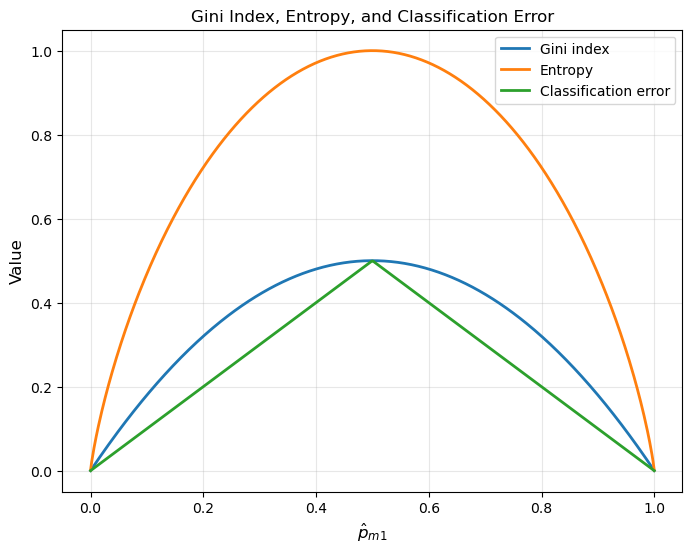

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(p, gini, label='Gini index', linewidth=2)
ax.plot(p, entropy, label='Entropy', linewidth=2)
ax.plot(p, class_error, label='Classification error', linewidth=2)
ax.set_xlabel(r'$\hat{p}_{m1}$', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Gini Index, Entropy, and Classification Error')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Interpretation:** All three measures are 0 when the node is pure ($\hat{p}_{m1}=0$ or $1$) and reach
their maximum at $\hat{p}_{m1}=0.5$ (maximal impurity). Entropy is scaled largest (peak 1), Gini index
peaks at 0.5, and classification error peaks at 0.5 but is the smallest/least sensitive of the three near
the extremes. This is why Gini index and entropy are preferred over classification error for growing
trees (they're more sensitive to node purity and therefore better guide the splitting process).

# Q8
In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will
seek to predict Sales using regression trees and related approaches,
treating the response as a quantitative variable.

(a) Split the data set into a training set and a test set.

(b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

(c) Use cross-validation in order to determine the optimal level of
tree complexity. Does pruning the tree improve the test MSE?

(d) Use the bagging approach in order to analyze this data. What
test MSE do you obtain? Use the feature_importance_ values to
determine which variables are most important.

(e) Use random forests to analyze this data. What test MSE do
you obtain? Use the feature_importance_ values to determine
which variables are most important. Describe the effect of m, the
number of variables considered at each split, on the error rate
obtained.

(f) Now analyze the data using BART, and report your results.

### (a) Splitting the Data into Training and Test Sets

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data
from ISLP.models import ModelSpec as MS

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

Carseats = load_data('Carseats')
Carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [4]:
model = MS(Carseats.columns.drop('Sales'), intercept=False)
D = model.fit_transform(Carseats)
feature_names = list(D.columns)
X = np.asarray(D)
y = Carseats['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 200, Test size: 200


### (b) Fit a Regression Tree to the Training Set

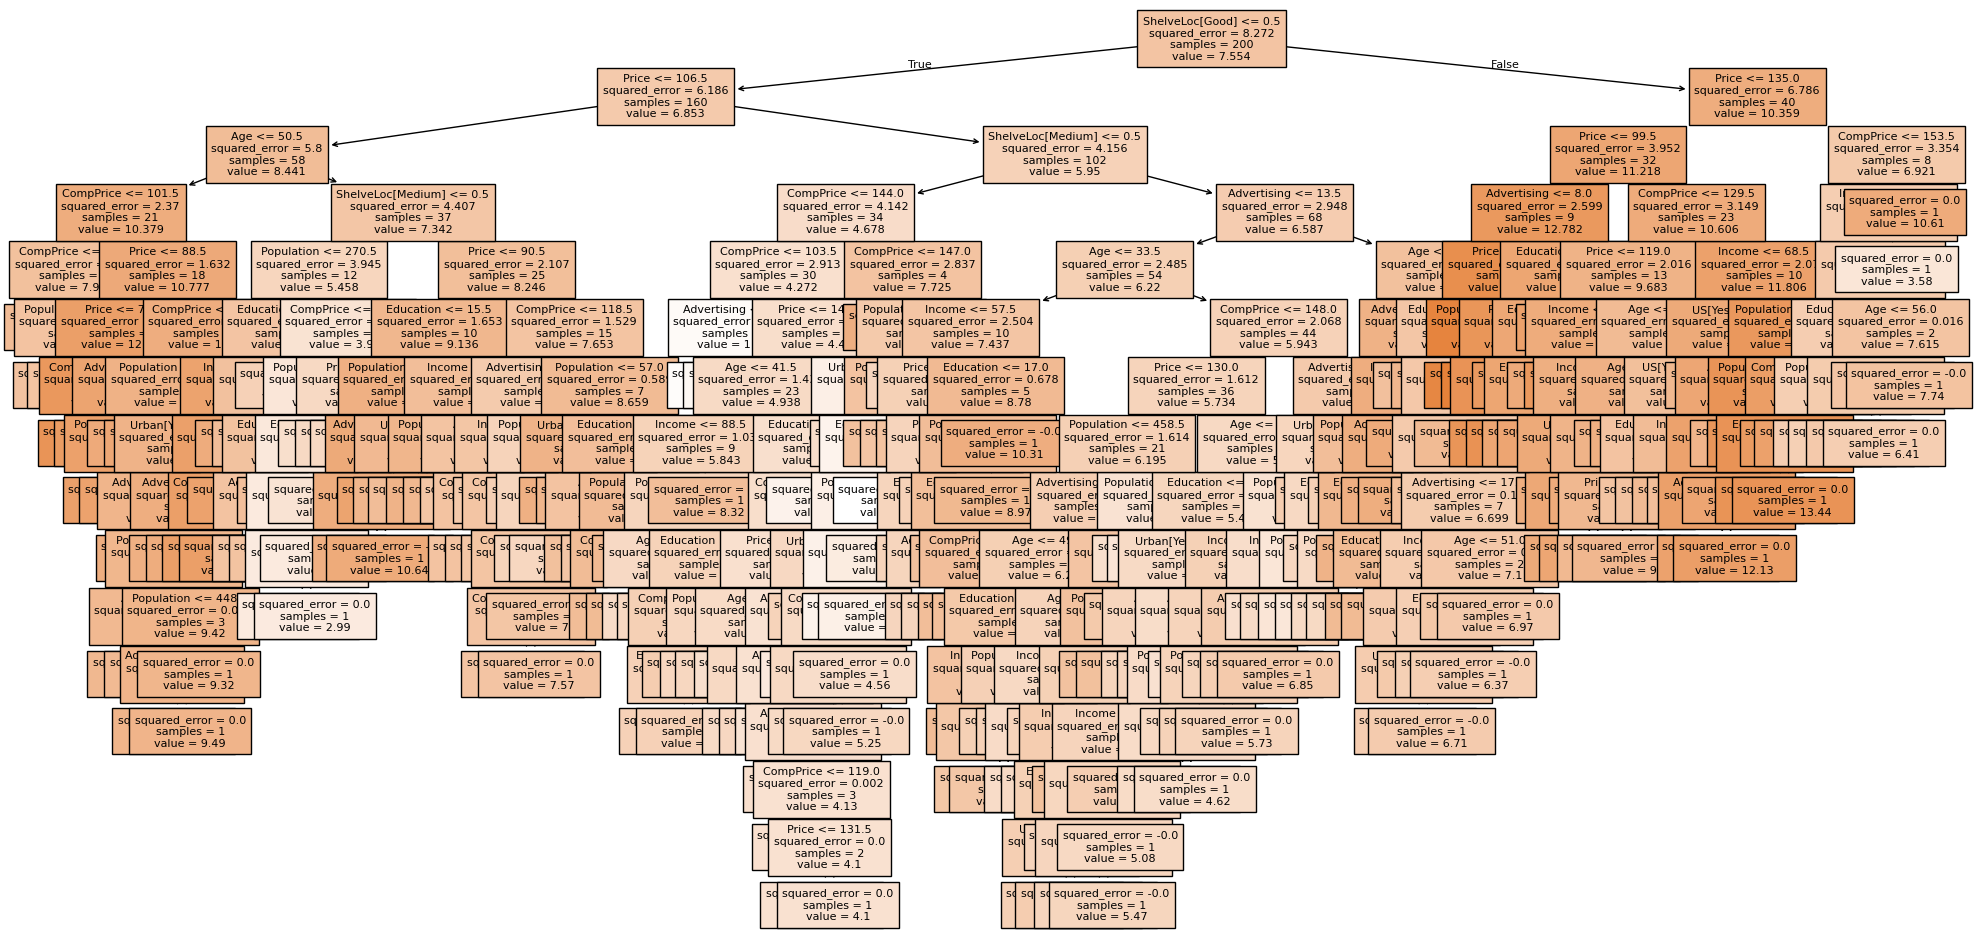

Unpruned tree - number of terminal nodes: 199
Test MSE (unpruned tree): 6.383


In [5]:
reg_tree = DecisionTreeRegressor(random_state=1)
reg_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(reg_tree, feature_names=feature_names, filled=True, fontsize=8, ax=ax)
plt.show()

pred = reg_tree.predict(X_test)
test_mse_unpruned = mean_squared_error(y_test, pred)
print(f"Unpruned tree - number of terminal nodes: {reg_tree.get_n_leaves()}")
print(f"Test MSE (unpruned tree): {test_mse_unpruned:.3f}")

In [6]:
print(f"Root split feature: {feature_names[reg_tree.tree_.feature[0]]}")
print(f"Root split threshold: {reg_tree.tree_.threshold[0]:.3f}")

Root split feature: ShelveLoc[Good]
Root split threshold: 0.500


**Interpretation:** With no depth or leaf-size constraints, the tree grows quite deep and overfits the
training data. The top-level splits are on `ShelveLoc` and `Price`, the two variables that have the
strongest relationship with `Sales`, which makes sense given their importance in the ISLP classification
tree example from the lab. Further down the tree, however, splits become much less interpretable and
increasingly reflect noise specific to the training set rather than genuine structure in `Sales`. This is
the classic bias-variance tradeoff of an unconstrained tree: very low training error (low bias) at the
cost of high variance, which is exactly what pruning in part (c) is meant to address.

### (c) Cost-Complexity Pruning with Cross-Validation

Best ccp_alpha: 0.1532
Pruned tree - number of terminal nodes: 10
Test MSE (pruned tree): 5.480
Test MSE (unpruned tree): 6.383


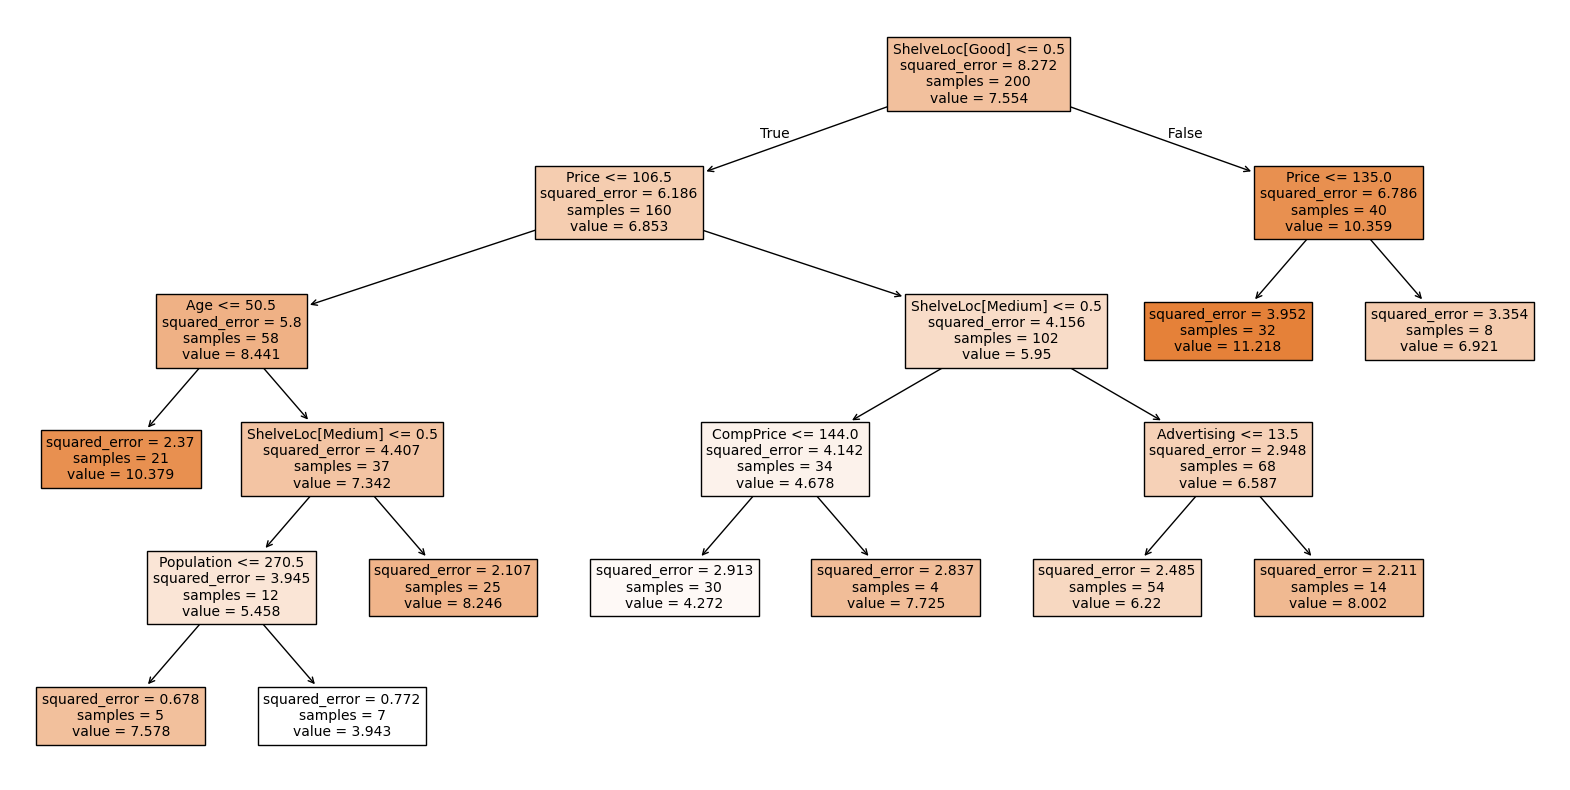

In [7]:
ccp_path = reg_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = ccp_path.ccp_alphas[ccp_path.ccp_alphas >= 0]

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
grid = GridSearchCV(DecisionTreeRegressor(random_state=1),
                     {'ccp_alpha': ccp_alphas},
                     refit=True,
                     cv=kfold,
                     scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_
pred_pruned = best_tree.predict(X_test)
test_mse_pruned = mean_squared_error(y_test, pred_pruned)

print(f"Best ccp_alpha: {grid.best_params_['ccp_alpha']:.4f}")
print(f"Pruned tree - number of terminal nodes: {best_tree.get_n_leaves()}")
print(f"Test MSE (pruned tree): {test_mse_pruned:.3f}")
print(f"Test MSE (unpruned tree): {test_mse_unpruned:.3f}")

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(best_tree, feature_names=feature_names, filled=True, fontsize=10, ax=ax)
plt.show()

**Interpretation:** Cross-validation selected a pruning parameter of ccp_alpha = 0.1532, which
collapses the original unpruned tree down to 10 terminal nodes. This pruned tree achieves a test
MSE of 5.480, compared to 6.383 for the unpruned tree, an improvement of roughly 0.9 (about a
14% reduction in test MSE). This confirms that the fully grown tree was overfitting the training
data: many of its deeper splits were capturing noise rather than real structure in `Sales`, and
removing them via cost-complexity pruning both simplifies the tree and improves its ability to
generalize to unseen data. So yes, pruning improves the test MSE in this case.

### (d) Bagging (RandomForestRegressor with max_features = all predictors)

In [8]:
p = X_train.shape[1]

bag_carseats = RandomForestRegressor(max_features=p, random_state=1, n_estimators=500)
bag_carseats.fit(X_train, y_train)

pred_bag = bag_carseats.predict(X_test)
test_mse_bag = mean_squared_error(y_test, pred_bag)
print(f"Test MSE (bagging): {test_mse_bag:.3f}")

feature_imp_bag = pd.DataFrame(
    {'importance': bag_carseats.feature_importances_}, index=feature_names
).sort_values('importance', ascending=False)
feature_imp_bag

Test MSE (bagging): 2.822


,importance
Price,0.298447
ShelveLoc[Good],0.231341
Age,0.106076
CompPrice,0.083819
ShelveLoc[Medium],0.083608
Advertising,0.058212
Income,0.052518
Population,0.046501
Education,0.028049
Urban[Yes],0.007330


**Interpretation:** Bagging substantially improves test MSE compared to both the unpruned tree
(6.383) and the pruned tree (5.480), dropping to 2.822, roughly a 48% reduction from the pruned
single tree. This is the expected benefit of bagging: averaging predictions across 500 bootstrapped
trees reduces variance without increasing bias, since a single deep tree is highly sensitive to the
particular training sample it saw. Looking at feature importance, `Price` (0.298) and `ShelveLoc[Good]`
(0.231) are by far the most important predictors of `Sales`, together accounting for over half of the
total importance, consistent with the earlier single-tree splits, which also chose these variables
first. `Age`, `CompPrice`, and `ShelveLoc[Medium]` form a second tier of moderately important
predictors, while `Urban` and `US` contribute almost nothing to predictive accuracy.

### (e) Random Forests

In [9]:
rf_carseats = RandomForestRegressor(max_features=p // 3, random_state=1, n_estimators=500)
rf_carseats.fit(X_train, y_train)

pred_rf = rf_carseats.predict(X_test)
test_mse_rf = mean_squared_error(y_test, pred_rf)
print(f"Test MSE (random forest, m = p/3): {test_mse_rf:.3f}")

feature_imp_rf = pd.DataFrame(
    {'importance': rf_carseats.feature_importances_}, index=feature_names
).sort_values('importance', ascending=False)
feature_imp_rf

Test MSE (random forest, m = p/3): 2.960


,importance
Price,0.251549
ShelveLoc[Good],0.168637
Age,0.113542
CompPrice,0.096210
Advertising,0.087617
Income,0.081517
Population,0.078082
ShelveLoc[Medium],0.049546
Education,0.048461
Urban[Yes],0.012491


**Interpretation:** Random forest with m = p/3 (using a subset of predictors at each split) achieves a
test MSE of 2.960, slightly higher than bagging's 2.822. This is a plausible outcome, not a contradiction:
in datasets like `Carseats` where one or two predictors (`Price`, `ShelveLoc`) are dominant, restricting
the variables available at each split can occasionally hurt performance slightly, since the trees are
sometimes forced to split on a weaker predictor when the strongest one isn't in the sampled subset.
Random forest's main benefit, decorrelating trees to reduce ensemble variance, pays off more
noticeably in datasets with many moderately-important, correlated predictors, which isn't quite the
case here.

Comparing feature importances to bagging, the overall ranking is similar (`Price` and `ShelveLoc[Good]`
remain the top two predictors), but the importance is more evenly distributed across the remaining
variables, such as `Advertising` (0.088), `Income` (0.082), and `Population` (0.078) all gain relative
importance compared to their bagging scores. This is the expected effect of limiting m: since `Price`
and `ShelveLoc` aren't guaranteed to be available at every split, other variables get more opportunities
to be chosen, spreading credit more evenly across predictors.

### Effect of m (number of variables considered at each split) on test MSE

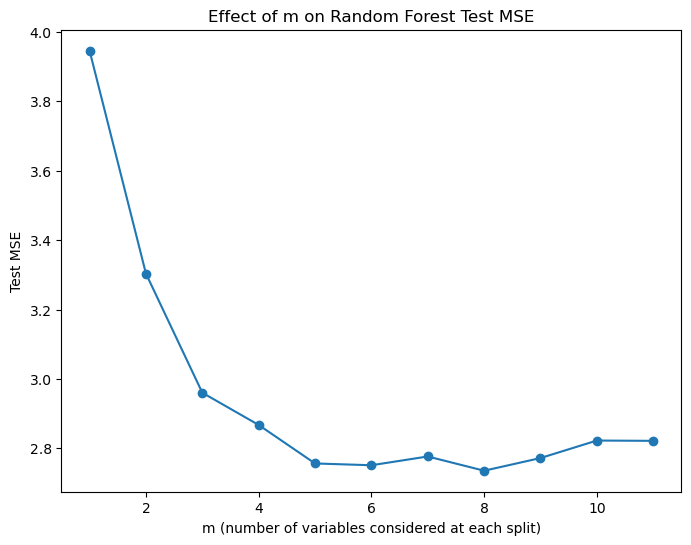

In [10]:
m_values = range(1, p + 1)
mse_by_m = []
for m in m_values:
    rf = RandomForestRegressor(max_features=m, random_state=1, n_estimators=500)
    rf.fit(X_train, y_train)
    mse_by_m.append(mean_squared_error(y_test, rf.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(list(m_values), mse_by_m, marker='o')
ax.set_xlabel('m (number of variables considered at each split)')
ax.set_ylabel('Test MSE')
ax.set_title('Effect of m on Random Forest Test MSE')
plt.show()

**Interpretation:** Test MSE is highest at m = 1 (≈3.94), where each split can only choose from a single
randomly-selected predictor, making individual trees weak and highly variable since the strongest
predictors (`Price`, `ShelveLoc`) are often excluded from consideration. MSE drops sharply as m increases
from 1 to 5, then flattens into a shallow minimum across m = 5 to m = 9 (roughly 2.73–2.78), with the
lowest point around m = 8. Beyond that, MSE increases slightly toward m = 10 and m = 11. Since
m = 11 = p (all 11 predictors), this endpoint is equivalent to bagging, and indeed matches the bagging
test MSE of 2.822 from part (d) almost exactly, which is a useful sanity check that the code is behaving
correctly. Overall, this confirms the textbook expectation: some decorrelation among trees (moderate m)
helps, but m too small starves trees of the informative predictors, and m too close to p reduces to
bagging with no further benefit.

### (f) BART

In [11]:
from ISLP.bart import BART

bart_carseats = BART(random_state=0, burnin=5, ndraw=15)
bart_carseats.fit(X_train, y_train)

yhat_bart = bart_carseats.predict(X_test.astype(np.float32))
test_mse_bart = mean_squared_error(y_test, yhat_bart)
print(f"Test MSE (BART): {test_mse_bart:.3f}")

# Variable importance: how often each variable was used as a splitting
# variable across all trees/draws
var_counts = pd.Series(
    bart_carseats.variable_inclusion_.mean(0), index=feature_names
).sort_values(ascending=False)
var_counts

Test MSE (BART): 1.443


Price                33.400000
CompPrice            31.800000
ShelveLoc[Good]      30.066667
ShelveLoc[Medium]    27.800000
Age                  27.600000
Advertising          27.266667
Population           26.733333
US[Yes]              25.800000
Income               25.733333
Urban[Yes]           25.333333
Education            24.066667
dtype: float64

**Interpretation:** BART achieves the lowest test MSE of all the methods tried in this problem: 1.443,
compared to 2.822 (bagging), 2.960 (random forest), 5.480 (pruned tree), and 6.383 (unpruned tree). This
is roughly a 49% improvement over bagging and about a 76% improvement over the single unpruned tree.
BART's Bayesian approach, where trees are kept intentionally small and are fit iteratively via a
"backfitting"-style MCMC procedure, with each tree only correcting the residual left by the others,
tends to avoid both the high variance of a single deep tree and the risk of any one tree dominating the
ensemble, which explains the strong performance here.

The variable inclusion counts (how often each predictor was used as a splitting variable across the
posterior draws) tell a noticeably different story than bagging/random forest's feature importances:
counts range narrowly from about 24 to 33, with `Price` and `CompPrice` used slightly more often than
the rest, but no predictor dominates the way `Price` and `ShelveLoc[Good]` did in bagging (where they
accounted for over half of total importance). This reflects a real methodological difference: because
BART's trees are shallow and each only models the residual left after the previous trees, there's less
opportunity, and less need, for any single tree to lean heavily on one or two dominant predictors, so
splitting gets spread more evenly across all available variables.

# Q9
This problem involves the OJ data set which is part of the ISLP package.

(a) Create a training set containing a random sample of 800 observations, and a test set containing the remaining observations.

(b) Fit a tree to the training data, with Purchase as the response
and the other variables as predictors. What is the training error
rate?

(c) Create a plot of the tree, and interpret the results. How many
terminal nodes does the tree have?

(d) Use the export_tree() function to produce a text summary of
the fitted tree. Pick one of the terminal nodes, and interpret the
information displayed.

(e) Predict the response on the test data, and produce a confusion
matrix comparing the test labels to the predicted test labels.
What is the test error rate?

(f) Use cross-validation on the training set in order to determine
the optimal tree size.

(g) Produce a plot with tree size on the x-axis and cross-validated
classification error rate on the y-axis.

(h) Which tree size corresponds to the lowest cross-validated classification error rate?

(i) Produce a pruned tree corresponding to the optimal tree size
obtained using cross-validation. If cross-validation does not lead
to selection of a pruned tree, then create a pruned tree with five
terminal nodes.

(j) Compare the training error rates between the pruned and unpruned trees. Which is higher?

(k) Compare the test error rates between the pruned and unpruned
trees. Which is higher?

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data
from ISLP.models import ModelSpec as MS

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix

OJ = load_data('OJ')
print(OJ.shape)
OJ.head()

(1070, 18)


,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


### (a) Train/Test Split

In [13]:
model = MS(OJ.columns.drop('Purchase'), intercept=False)
D = model.fit_transform(OJ)
feature_names = list(D.columns)
X = np.asarray(D)
y = OJ['Purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=800, random_state=1)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 800, Test size: 270


### (b) Fit a Classification Tree

In [14]:
clf = DecisionTreeClassifier(random_state=1)
clf.fit(X_train, y_train)

train_pred = clf.predict(X_train)
train_error = np.mean(train_pred != y_train)
print(f"Training error rate: {train_error:.4f}")
print(f"Number of terminal nodes: {clf.get_n_leaves()}")

Training error rate: 0.0100
Number of terminal nodes: 163


### (c) Plot the Tree

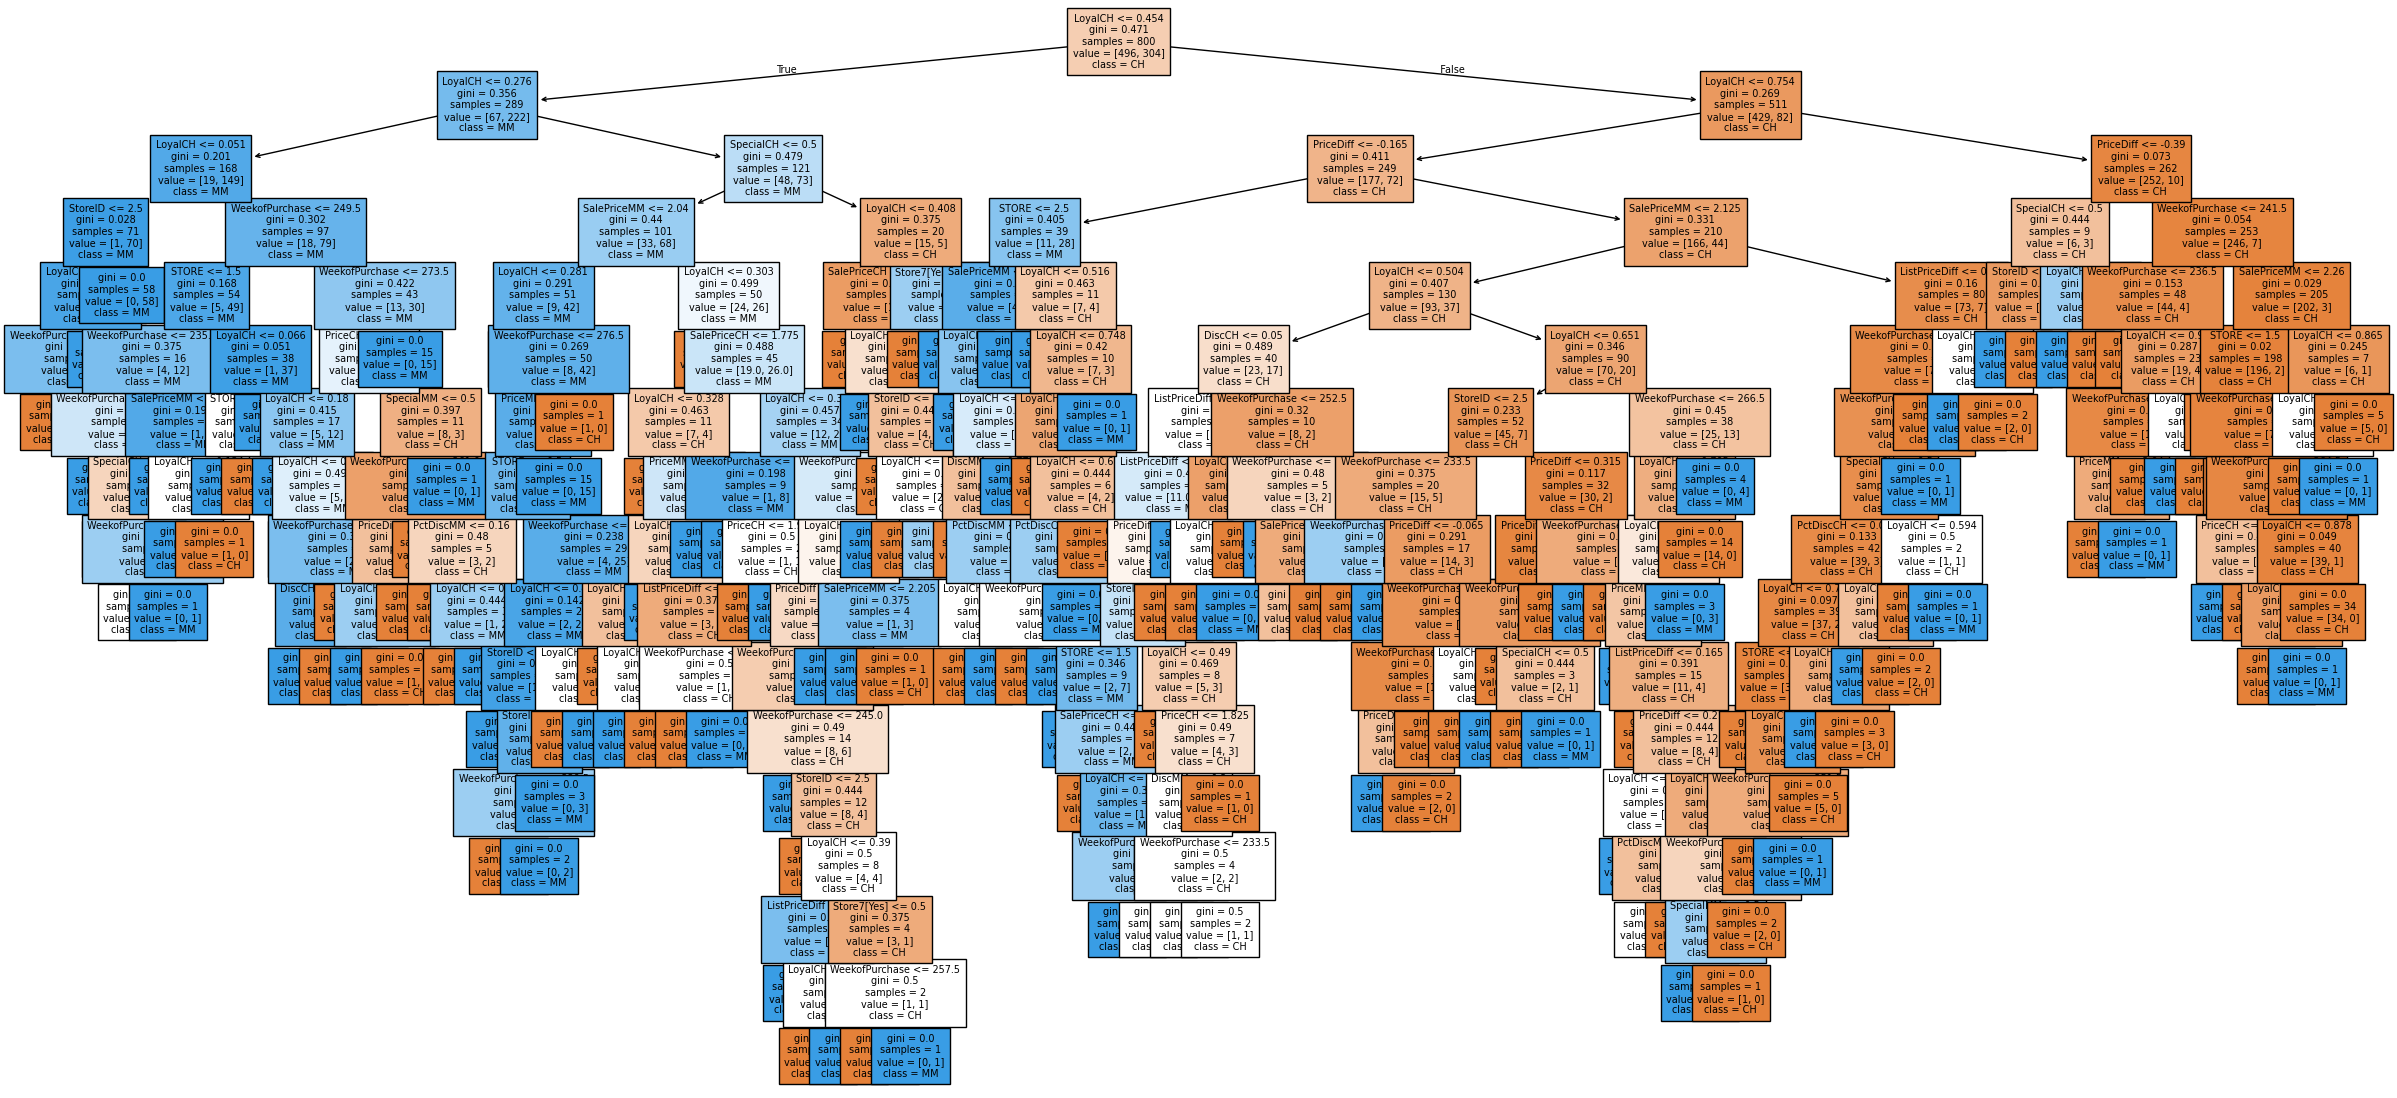

Number of terminal nodes: 163


In [15]:
fig, ax = plt.subplots(figsize=(30, 14))
plot_tree(clf, feature_names=feature_names, class_names=clf.classes_,
          filled=True, fontsize=7, ax=ax)
plt.show()

print(f"Number of terminal nodes: {clf.get_n_leaves()}")

In [16]:
print(f"Root split feature: {feature_names[clf.tree_.feature[0]]}")
print(f"Root split threshold: {clf.tree_.threshold[0]:.3f}")

Root split feature: LoyalCH
Root split threshold: 0.454


**Interpretation:** The root split is almost always on `LoyalCH` (the customer's brand loyalty toward
Citrus Hill), which makes intuitive sense. Brand loyalty is a direct behavioral signal of purchase intent,
so it dominates as the single most informative predictor. Customers with high `LoyalCH` values are
predicted to purchase `CH`, while those with low values are predicted to purchase `MM`. Further down the
tree, splits tend to involve price and discount variables (e.g. `PriceDiff`, `DiscCH`, `DiscMM`), which
refine the prediction for customers in the "undecided" middle range of brand loyalty, where price
sensitivity, rather than loyalty alone, becomes the deciding factor.

### (d) Text summary of the Tree (export_text is scikit-learn's equivalent)

In [17]:
tree_text = export_text(clf, feature_names=feature_names, max_depth=3)
print(tree_text)

|--- LoyalCH <= 0.45
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.05
|   |   |   |--- StoreID <= 2.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- StoreID >  2.50
|   |   |   |   |--- class: MM
|   |   |--- LoyalCH >  0.05
|   |   |   |--- WeekofPurchase <= 249.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- WeekofPurchase >  249.50
|   |   |   |   |--- truncated branch of depth 7
|   |--- LoyalCH >  0.28
|   |   |--- SpecialCH <= 0.50
|   |   |   |--- SalePriceMM <= 2.04
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- SalePriceMM >  2.04
|   |   |   |   |--- truncated branch of depth 13
|   |   |--- SpecialCH >  0.50
|   |   |   |--- LoyalCH <= 0.41
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- LoyalCH >  0.41
|   |   |   |   |--- truncated branch of depth 2
|--- LoyalCH >  0.45
|   |--- LoyalCH <= 0.75
|   |   |--- PriceDiff <= -0.16
|   |   |   |--- STORE <= 2.50
|   |   |   |   |--- truncated bra

**Interpretation:** One terminal node of the tree is reached when `LoyalCH <= 0.28` (and any preceding
conditions on that branch are satisfied). This leaf predicts `class: MM`, meaning customers with brand
loyalty to Citrus Hill at or below 0.28 are classified as Minute Maid purchasers. This matches the overall
pattern from the root split: low `LoyalCH` values consistently push predictions toward `MM`.

### (e) Predict on Test Data + Confusion Matrix

In [18]:
test_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, test_pred, labels=clf.classes_)
cm_df = pd.DataFrame(cm, index=[f'True {c}' for c in clf.classes_],
                      columns=[f'Pred {c}' for c in clf.classes_])
print(cm_df)

test_error = np.mean(test_pred != y_test)
print(f"\nTest error rate: {test_error:.4f}")

         Pred CH  Pred MM
True CH      132       25
True MM       41       72

Test error rate: 0.2444


**Interpretation:** The unpruned tree achieves a test error rate of 0.2444, misclassifying 66 out of
270 test observations (41 + 25), for a test accuracy of about 75.6%. Breaking this down by class:

- **CH predictions:** the tree correctly identifies 132 of 157 true `CH` purchases (recall ≈ 84.1%),
  but 25 true `CH` customers are misclassified as `MM`.
- **MM predictions:** the tree correctly identifies 72 of 113 true `MM` purchases (recall ≈ 63.7%),
  while 41 true `MM` customers are misclassified as `CH`.

The tree performs noticeably better at identifying `CH` purchasers than `MM` purchasers, both in recall
(84.1% vs. 63.7%) and in raw error counts, where `MM` customers are misclassified almost twice as often
(41) as `CH` customers (25). This asymmetry lines up with the class imbalance in the training data itself:
`CH` makes up about 62% of training observations versus 38% for `MM`, so the tree has more examples to
learn `CH`'s decision boundary from, and in ambiguous regions a bias toward predicting the majority class
`CH` is a reasonably safe default that pays off more often than not.


In [19]:
y_train.value_counts(normalize=True)

Purchase
CH    0.62
MM    0.38
Name: proportion, dtype: float64

### (f) Cross-validation to Determine Optimal Tree Size

In [20]:
ccp_path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = ccp_path.ccp_alphas[ccp_path.ccp_alphas >= 0]

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid = GridSearchCV(DecisionTreeClassifier(random_state=1),
                     {'ccp_alpha': ccp_alphas},
                     refit=True,
                     cv=kfold,
                     scoring='accuracy')
grid.fit(X_train, y_train)

print(f"Best ccp_alpha: {grid.best_params_['ccp_alpha']:.5f}")

Best ccp_alpha: 0.00481


### (g) Plot Tree Size vs. Cross-Validated Classification Error Rate

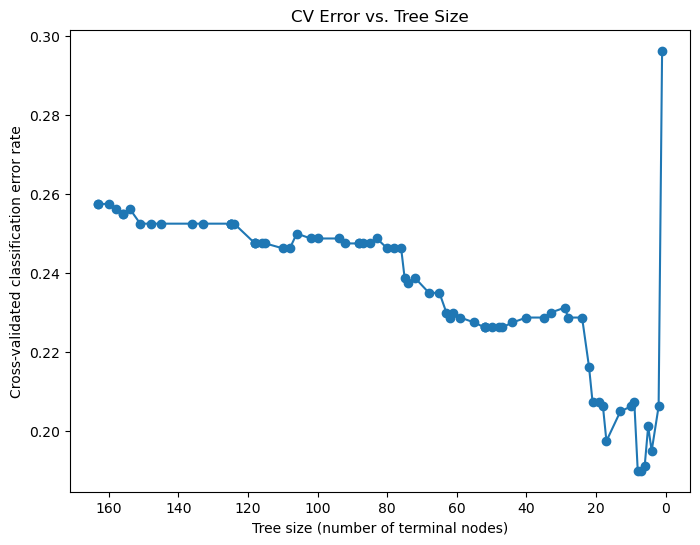

In [21]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_error = 1 - cv_results['mean_test_score']

n_leaves = []
for alpha in ccp_alphas:
    t = DecisionTreeClassifier(random_state=1, ccp_alpha=alpha)
    t.fit(X_train, y_train)
    n_leaves.append(t.get_n_leaves())

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_leaves, cv_error, marker='o')
ax.set_xlabel('Tree size (number of terminal nodes)')
ax.set_ylabel('Cross-validated classification error rate')
ax.set_title('CV Error vs. Tree Size')
ax.invert_xaxis()
plt.show()

**Interpretation:** Note that the x-axis is inverted (large trees on the left, small trees on the right),
since `ax.invert_xaxis()` was used to match the visual convention of "more pruning" moving left to right.

For most of the range, trees with roughly 80 to 160 terminal nodes, cross-validated error stays fairly
flat and high, hovering around 0.25 to 0.26. This indicates that removing nodes in this range doesn't
meaningfully change predictive performance, since these are likely deep, low-value splits that mostly
capture noise. Error begins dropping more noticeably once tree size falls below about 60 terminal nodes,
and drops sharply in the 5–20 node range, reaching its lowest values (around 0.19) somewhere in the
5–10 node range. Beyond that point, pruning too aggressively hurts performance: the tree with just 1–2
terminal nodes has a CV error close to 0.30, worse than almost any other size, since a tree that small
can no longer capture the real relationship between the predictors and `Purchase` at all.

This pattern is the classic bias-variance tradeoff for tree pruning: very large trees overfit (high
variance), extremely small trees underfit (high bias), and the optimal tree size sits in between, where
CV error is minimized.

### (h) Tree Size with Lowest CV Error

In [22]:
best_idx = np.argmin(cv_error.values)
best_size = n_leaves[best_idx]
print(f"Optimal tree size (lowest CV error): {best_size} terminal nodes")

Optimal tree size (lowest CV error): 8 terminal nodes


**Interpretation:** The tree size that minimizes cross-validated classification error is 8 terminal
nodes. This aligns with the plot from part (g), where CV error dropped sharply once tree size fell
below roughly 20 nodes and reached its lowest values in the 5–10 node range. 8 node range falls right in that
window. This means a substantially pruned tree, retaining only about 5% of the original 163 terminal
nodes, generalizes better (according to cross-validation) than the full unpruned tree, reinforcing that
most of the extra splits in the fully grown tree were fitting noise rather than real structure in
`Purchase`.

### (i) Pruned Tree at the Optimal Size

Pruned tree terminal nodes: 8


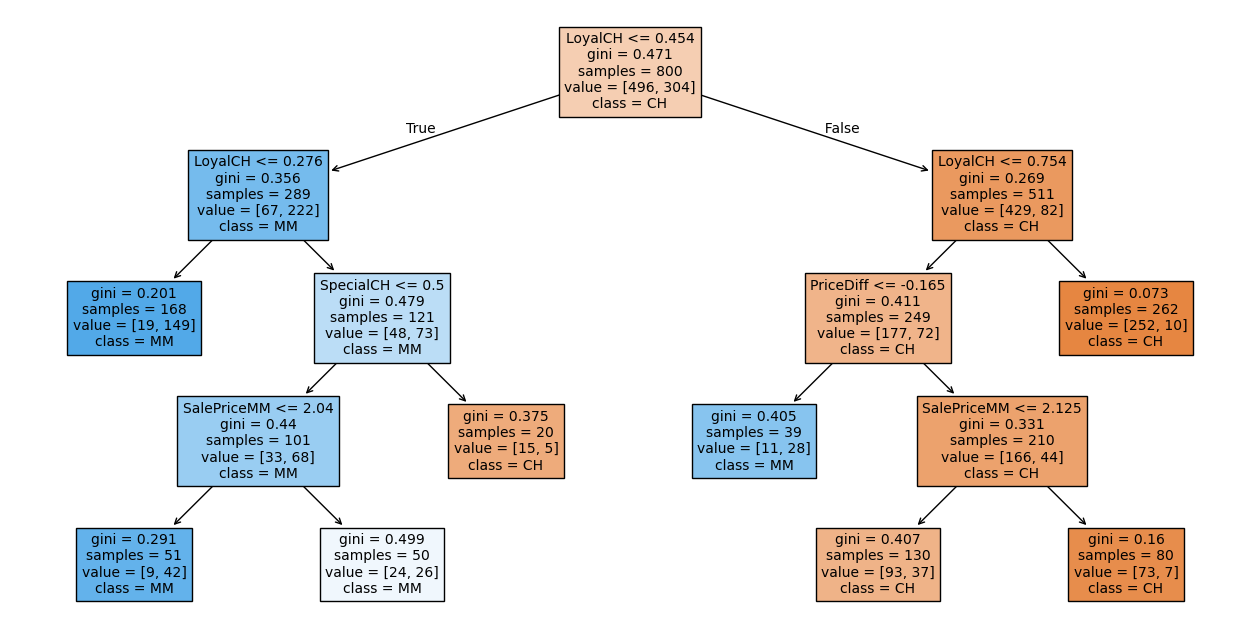

In [23]:
best_alpha = ccp_alphas[best_idx]
pruned_tree = DecisionTreeClassifier(random_state=1, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

print(f"Pruned tree terminal nodes: {pruned_tree.get_n_leaves()}")

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(pruned_tree, feature_names=feature_names, class_names=clf.classes_,
          filled=True, fontsize=10, ax=ax)
plt.show()

**Interpretation:** The pruned tree confirms `LoyalCH` as by far the dominant predictor. It's used at
the root and at both nodes directly below it, splitting the data into three loyalty tiers before any other
variable is considered. Customers with `LoyalCH` > 0.754 are classified `CH` with very high confidence
(gini = 0.073, 252 of 262 samples are `CH`). This is the purest leaf in the tree, showing that very
high brand loyalty is an almost decisive signal on its own. At the other extreme, customers with
`LoyalCH` ≤ 0.276 are classified `MM` with reasonable confidence (gini = 0.201, 149 of 168 samples are
`MM`).

The "middle" loyalty range (roughly 0.276–0.754) is where the tree needs additional variables to
resolve the prediction, since brand loyalty alone isn't decisive for these customers. On the low-loyalty
side, `SpecialCH` and `SalePriceMM` refine the split. Customers here remain mostly `MM`, though one leaf
(50 samples, gini = 0.499) is nearly a coin flip, indicating the tree still can't cleanly separate a
subset of these customers. On the high-loyalty side, `PriceDiff` and `SalePriceMM` come into play. Notably, when `PriceDiff` ≤ -0.165 (meaning Minute Maid is priced meaningfully cheaper than Citrus
Hill), the tree flips its prediction to `MM` even for these moderately loyal customers (28 of 39 samples),
showing that a large enough price incentive can override brand loyalty.

Overall, the tree tells a coherent story: brand loyalty drives the decision for customers at the extremes,
while for customers in between, price becomes the deciding factor, which matches basic economic
intuition about brand-loyal but still price-sensitive consumers.

### (j) & (k) Comparing Training and Test Error: Pruned vs. Unpruned

In [24]:
train_pred_pruned = pruned_tree.predict(X_train)
train_error_pruned = np.mean(train_pred_pruned != y_train)

test_pred_pruned = pruned_tree.predict(X_test)
test_error_pruned = np.mean(test_pred_pruned != y_test)

comparison = pd.DataFrame({
    'Unpruned': [train_error, test_error],
    'Pruned':   [train_error_pruned, test_error_pruned]
}, index=['Training error', 'Test error'])
comparison

,Unpruned,Pruned
Training error,0.010000,0.152500
Test error,0.244444,0.181481


**Interpretation:**

**(j) Training error comparison:** The unpruned tree has a training error of 0.010 (1%), while the pruned
tree has a training error of 0.1525 (15.25%). The pruned tree's training error is substantially higher.
This is expected: the unpruned tree has 163 terminal nodes, giving it enough flexibility to fit the
training data almost perfectly (and, unsurprisingly, to overfit), while the pruned tree's 8 terminal nodes
constrain it to a much simpler decision boundary that cannot memorize every training observation.

**(k) Test error comparison:** Despite its much higher training error, the pruned tree achieves a *lower*
test error (0.1815, or 18.15%) than the unpruned tree (0.2444, or 24.44%), roughly a 26% relative
reduction in test error. This is the central lesson of the bias-variance tradeoff in this assignment: the
unpruned tree's near-perfect training fit came at the cost of memorizing noise specific to the training
set, which hurt its ability to generalize. The pruned tree sacrifices training accuracy but generalizes
better, confirming that cross-validation successfully selected a tree size that reduces overfitting
without discarding the real signal in the data (`LoyalCH`, `PriceDiff`, etc., as seen in part (i)).

Together, (j) and (k) demonstrate the tradeoff directly: **higher training error paired with lower test
error** is exactly the signature of successful pruning. The goal was never to fit the training data
perfectly, but to generalize well to unseen data.